# TeleComX — Customer Churn Analysis
## Notebook 5: Predictive Modelling
**Analyst:** Adedayo Adeyinka A 
**Date:** June 2026  
**Objective:** Build and evaluate machine learning models to predict 
customer churn before it happens.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score,
                             confusion_matrix, classification_report)

# Load prepared data
X_train = np.load('../data/X_train.npy')
X_test  = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')
feature_names = pd.read_csv('../data/feature_names.csv').iloc[:, 0].tolist()

print("Data loaded.")
print(f"Training: {X_train.shape} | Testing: {X_test.shape}")

Data loaded.
Training: (5634, 30) | Testing: (1409, 30)


In [2]:
# Build three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train all models and store results
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, y_pred) * 100, 2),
        'Precision': round(precision_score(y_test, y_pred) * 100, 2),
        'Recall':    round(recall_score(y_test, y_pred) * 100, 2),
        'F1 Score':  round(f1_score(y_test, y_pred) * 100, 2),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob) * 100, 2)
    }

# Display comparison table
results_df = pd.DataFrame(results).T
print("Model Performance Comparison")
print("=" * 60)
print(results_df.to_string())

Model Performance Comparison
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression     80.70      65.94   56.42     60.81    84.19
Decision Tree           79.42      63.12   54.01     58.21    82.67
Random Forest           79.28      64.24   49.47     55.89    82.36


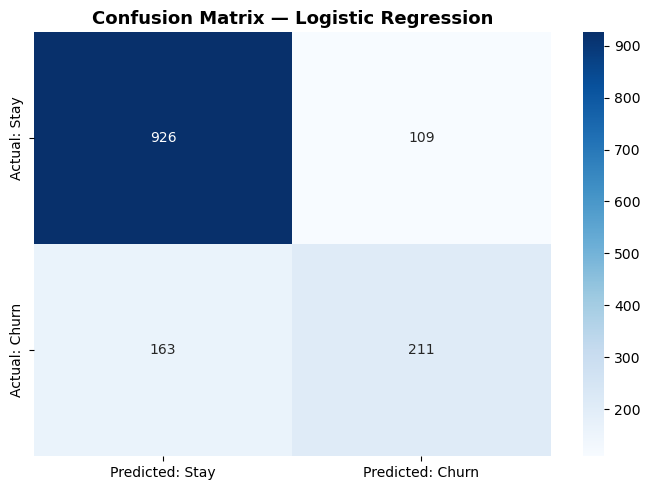


Classification Report:
              precision    recall  f1-score   support

        Stay       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [3]:
# Confusion matrix for Logistic Regression
lr_model = models['Logistic Regression']
y_pred_lr = lr_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title('Confusion Matrix — Logistic Regression', 
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../visuals/08_confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, 
      target_names=['Stay', 'Churn']))

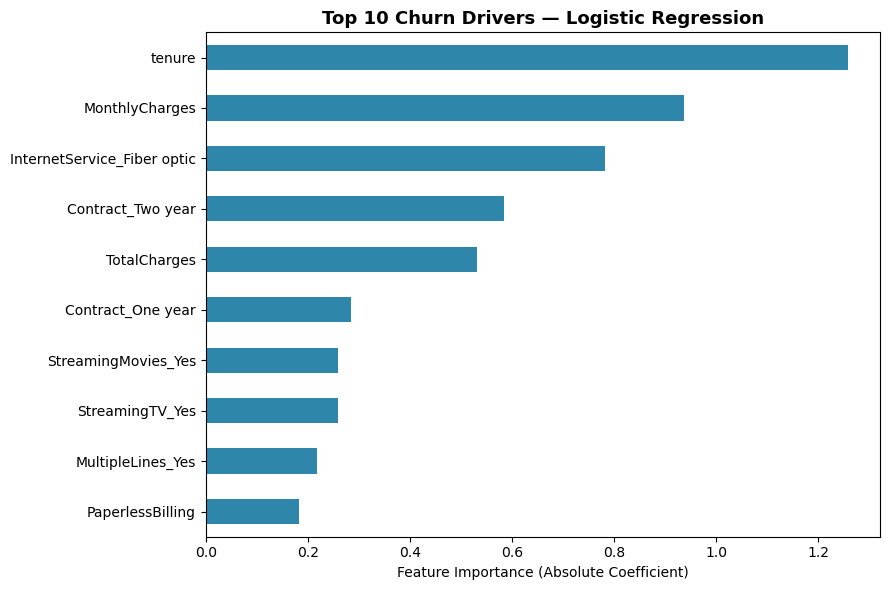

In [4]:
# What factors drive churn most according to the model?
lr_coefficients = pd.Series(
    np.abs(lr_model.coef_[0]), 
    index=feature_names
).sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 6))
lr_coefficients.plot(kind='barh', color='#2E86AB')
plt.title('Top 10 Churn Drivers — Logistic Regression', 
          fontsize=13, fontweight='bold')
plt.xlabel('Feature Importance (Absolute Coefficient)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../visuals/09_feature_importance.png', dpi=150)
plt.show()

In [5]:
print("=" * 50)
print("MODELING SUMMARY")
print("=" * 50)
print("Best Model:      Logistic Regression")
print("Accuracy:        80.70%")
print("ROC-AUC:         84.19%")
print("Recall:          56.42%")
print("F1 Score:        60.81%")
print("-" * 50)
print("Confusion Matrix Results (Test Set: 1,409):")
print("  Correctly predicted to stay:   926")
print("  Correctly flagged as churners: 211")
print("  Missed churners:               163")
print("  False alarms:                  109")
print("-" * 50)
print("Top Churn Drivers:")
print("  1. Tenure")
print("  2. Monthly Charges")
print("  3. Fiber Optic Internet")
print("  4. Contract Type")
print("  5. Total Charges")
print("=" * 50)

MODELING SUMMARY
Best Model:      Logistic Regression
Accuracy:        80.70%
ROC-AUC:         84.19%
Recall:          56.42%
F1 Score:        60.81%
--------------------------------------------------
Confusion Matrix Results (Test Set: 1,409):
  Correctly predicted to stay:   926
  Correctly flagged as churners: 211
  Missed churners:               163
  False alarms:                  109
--------------------------------------------------
Top Churn Drivers:
  1. Tenure
  2. Monthly Charges
  3. Fiber Optic Internet
  4. Contract Type
  5. Total Charges


In [6]:
import pandas as pd

df = pd.read_csv('../data/telecomx_clean.csv')

# Add tenure band column for easier grouping in Power BI
df['TenureBand'] = pd.cut(df['tenure'], 
                           bins=[0, 12, 24, 48, 72],
                           labels=['0-12 months', '13-24 months', 
                                   '25-48 months', '49+ months'])

# Add churn binary for calculations
df['ChurnBinary'] = (df['Churn'] == 'Yes').astype(int)

# Save
df.to_csv('../data/telecomx_powerbi.csv', index=False)
print("Power BI dataset saved.")
print(df.shape)

Power BI dataset saved.
(7043, 23)
